In [3]:
library(eRm) # digunakan untuk pemodelan rasch
library(dplyr) 
library(readxl) # digunakan untuk membaca file excel
library(psych)
library(ggplot2) # digunakan untuk membuat grafik
library(tidyr) # digunakan untuk merapikan data

In [134]:
source("fungsi/plotICC.R")
source("fungsi/wrightmap.R")

In [4]:
data <- read_excel("baruuu.xlsx") # membaca data menggunakan fungsi readxl dan menyimpannya di dataframe data
head(data, 5) # menampilkan 5 data teratas (mengecek apakah data sudah dibaca dengan benar oleh R)

S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
3,3,1,3,3,3,0,3,3,4,4,3
3,3,1,4,2,3,2,2,2,3,2,2
2,3,1,2,0,3,4,2,2,1,2,3
2,3,1,3,0,1,0,4,3,1,2,3
3,4,1,4,1,2,0,0,2,4,3,2


## 1. Estimasi Parameter Item Soal
### 1.1 Partial Credit Model (PCM)
PCM digunakan untuk mengukur probabilitas response pada soal dengan jawaban bersakala kategori. Misalnya soal esai dengan rentang jawaban 0-4. 0 adalah nilai terendah dan 4 adalah nilai tertiggi apabila dapat menjawab soal dengan benar. Sementara itu, nilai 1, 2 dan 3 digunakan sebagai kredit parsial. 

Untuk Menjelaskan probabilitas response masing-masing kategori, model menggnakan lebih dari satu ICC. 


Cara pcm menghitung probabilitas jawaban:

**Step 1 — Ratio of adjacent probabilities:**

$$ \frac{\Pr(U_{pi} = k \mid \theta_p, \delta_{i1}, \dots, \delta_{im})}{\Pr(U_{pi} = k-1 \mid \theta_p, \delta_{i1}, \dots, \delta_{im})} = \exp(\theta_p - \delta_{ik}) $$

**Step 2 — Take the log to get the linear form:**

$$ \log\left( \frac{\Pr(U_{pi} = k \mid \theta_p, \delta_{i1}, \dots, \delta_{im})}{\Pr(U_{pi} = k-1 \mid \theta_p, \delta_{i1}, \dots, \delta_{im})} \right) = \theta_p - \delta_{ik} $$

where $k = 1, 2, \dots, m$, and $m$ is the maximum score for item $i$ (so $U_{pi} \in \{0, 1, \dots, m\}$).

For k=1k=1 (comparing category 1 vs 0):

$$ \log\left( \frac{\Pr(U_{pi} = 1 \mid \theta_p, \delta_{i1}, \delta_{i2})}{\Pr(U_{pi} = 0 \mid \theta_p, \delta_{i1}, \delta_{i2})} \right) = \theta_p - \delta_{i1} $$

For k=2k=2 (comparing category 2 vs 1):

$$ \log\left( \frac{\Pr(U_{pi} = 2 \mid \theta_p, \delta_{i1}, \delta_{i2})}{\Pr(U_{pi} = 1 \mid \theta_p, \delta_{i1}, \delta_{i2})} \right) = \theta_p - \delta_{i2} $$


CML
$$ L_u(\mathbf{r}, \boldsymbol{\beta}) = \frac{ \exp\left( -\sum_{i=1}^{I} c_i \beta_i \right) }{ \prod_{p=1}^{P} \gamma_{r_p}(\boldsymbol{\beta}) } $$
- $c_i = \sum_{p=1}^{P} u_{pi}$ (item sum score)
- $r_p = \sum_{i=1}^{I} u_{pi}$ (person raw score)
- $\gamma_{r_p}(\boldsymbol{\beta}) = \sum_{\mathbf{y} \in \mathcal{Y}_{r_p}} \exp\left( -\sum_{i=1}^{I} y_i \beta_i \right)$
- $\mathcal{Y}_{r_p}$ is the set of all response vectors with sum $r_p$

$$ \gamma_{r_p}(\boldsymbol{\beta}) = \sum_{\mathbf{y} \in \mathcal{Y}_{r_p}} \exp\left( -\sum_{i=1}^{I} \sum_{k=1}^{y_i} \beta_{ik} \right) $$

In [12]:
rasch_model_pcm <- PCM(data)
summary(rasch_model_pcm)


Results of PCM estimation: 

Call:  PCM(X = data) 

Conditional log-likelihood: -1178.411 
Number of iterations: 51 
Number of parameters: 45 

Item (Category) Difficulty Parameters (eta): with 0.95 CI:
       Estimate Std. Error lower CI upper CI
S1.c2     1.526      0.352    0.836    2.217
S1.c3     0.387      0.273   -0.148    0.922
S1.c4     4.560      1.005    2.590    6.529
S2.c1    -0.728      0.692   -2.084    0.627
S2.c2    -2.342      0.577   -3.473   -1.211
S2.c3    -2.560      0.562   -3.662   -1.458
S2.c4    -1.073      0.602   -2.251    0.106
S3.c1     0.447      0.210    0.036    0.858
S3.c2     3.406      0.597    2.237    4.575
S4.c1    -2.914      0.703   -4.292   -1.536
S4.c2    -2.609      0.688   -3.959   -1.260
S4.c3    -2.081      0.682   -3.418   -0.744
S4.c4    -0.347      0.757   -1.830    1.137
S5.c1     0.040      0.275   -0.499    0.580
S5.c2     0.222      0.289   -0.344    0.788
S5.c3     0.970      0.346    0.293    1.648
S5.c4     2.582      0.528    1

## 2. Evaluasi

### 2.1 Person Item Map


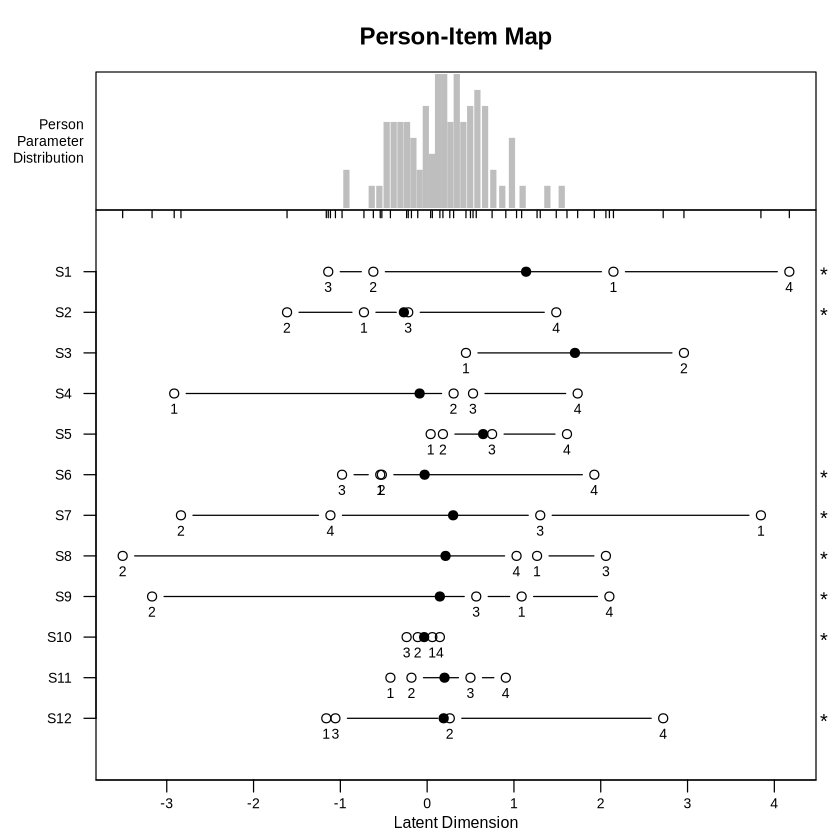

In [8]:
plotPImap(rasch_model_pcm)

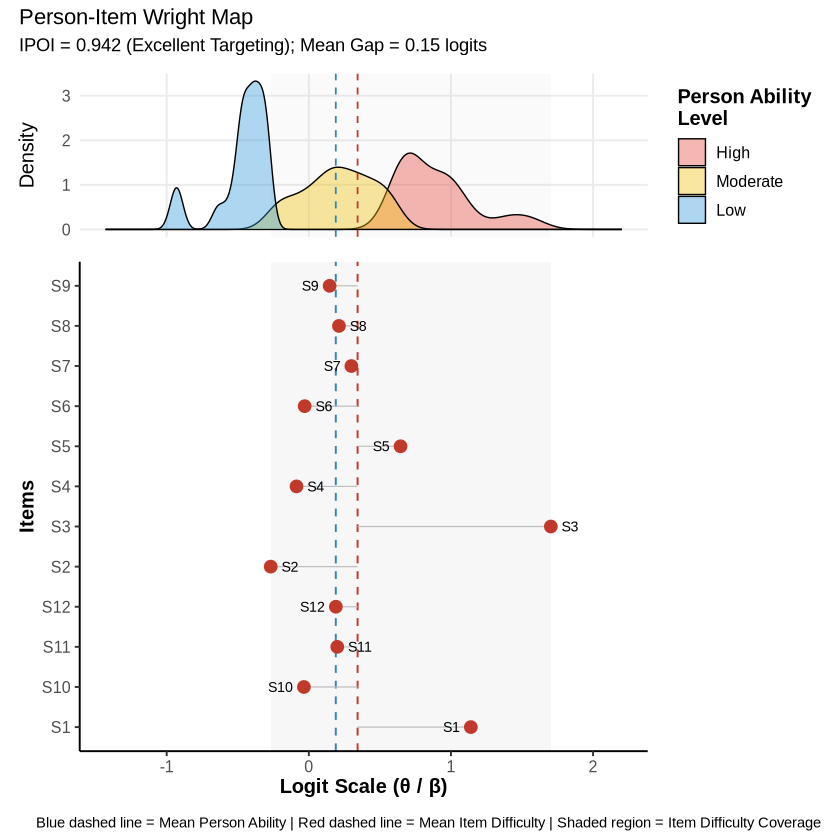

In [133]:
plot_wright_map(rasch_model_pcm)

### 2.2 Empirical ICCs

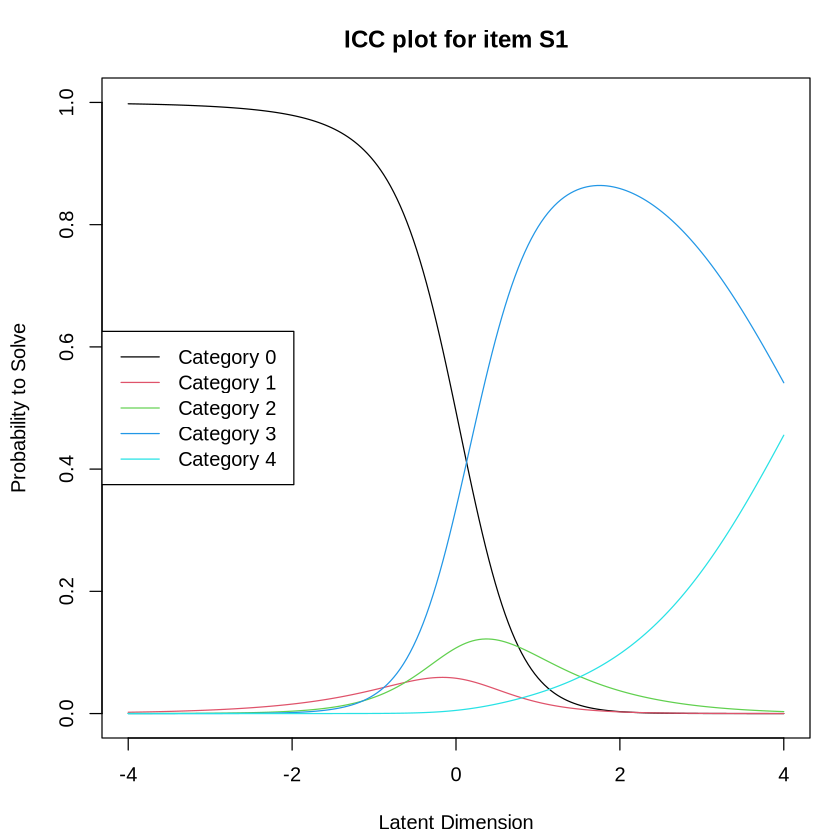

In [10]:
plotICC(rasch_model_pcm, item.subset = "S1")

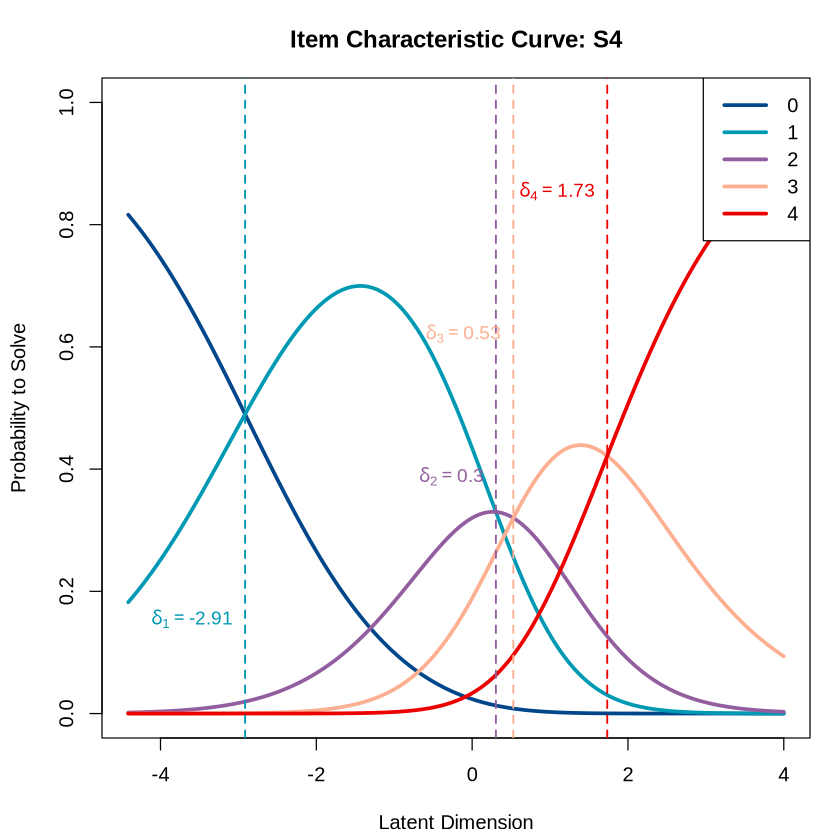

In [132]:
plot_icc_clean(rasch_model_pcm, "S4")

### 2.3 Andersen’s Likelihood Ratio Test and Graphical Test

In [89]:
lrt_mean_split <- LRtest(rasch_model_pcm, splitcr = "mean")
lrt_mean_split

Warning message in LRtest.Rm(rasch_model_pcm, splitcr = "mean"):
“
The following items were excluded due to inappropriate response patterns within
subgroups:
S1 S3 S5 S12 S4 S9 S2 S7 S8

Full and subgroup models are estimated without these items!”



Andersen LR-test: 
LR-value: 10.051 
Chi-square df: 11 
p-value:  0.526 


To evaluate whether the item parameters remain stable across different strata of the sample, Andersen’s global Likelihood Ratio (LR) test was executed using a mean-score split criterion. The estimation engine yielded a non-significant global fit statistic:

$$\chi^2 = 10.051, \quad df = 11, \quad p = 0.526$$

While a $p$-value of 0.526 conventionally indicates a perfect model fit, the CML algorithm generated a critical structural warning: nine items (S1, S2, S3, S4, S5, S7, S8, S9, and S12) were mechanically excluded from the calculation due to inappropriate response patterns within the partitioned subgroups.This exclusion is an artifact of the mathematical estimation engine rather than an item defect. Because the mean split highly segregated the moderate sample size into polarized ability groups, extreme response categories on these nine items suffered from category sparsity (zero observations in specific score cells). Within the strict framework of CML estimation, zero-cell counts cause threshold parameters to stretch toward infinity, rendering calculation impossible.As a result, the global LR test was uninformative for the full scale, as it only evaluated a stable three-item fragment (S6, S10, and S11). To maintain the exploratory integrity of the study and retain all 12 items, global invariance testing was bypassed in favor of a sample-independent evaluation of item precision and structural reliability.

#### 2.4 Uji Unidimensionality

In [14]:
mloef_median <- MLoef(rasch_model_pcm, splitcr = "median")
mloef_median


Martin-Loef-Test (split criterion: median)
LR-value: 166.622 
Chi-square df: 527 
p-value: 1 


### 2.4 Item and Person fit
Finally, we can obtain fit statistics for individual items and persons. As we have explained in Section 4.3.3, infit and outfit statistics are commonly used for checking the fit of individual items or persons in the Rasch model. As was also mentioned in this section, the calculation of Rasch residuals is based on the estimates of the item and person parameters. The details on the estimation of the person parameters will be explained below. First, we calculate the infit and outfit statistics for all items in our data set using the following command.

#### 2.4.1 Uji Validitas Soal (Validitas Konstruk)

In [15]:
itemfit(person.parameter(rasch_model_pcm))


Itemfit Statistics: 
      Chisq  df p-value Outfit MSQ Infit MSQ Outfit t Infit t Discrim
S1   76.388 101   0.968      0.749     0.785   -1.909  -2.282   0.606
S2   93.314 101   0.694      0.915     0.962   -0.521  -0.203   0.249
S3   90.663 101   0.760      0.889     0.914   -0.944  -0.724   0.432
S4  101.708 101   0.462      0.997     0.994    0.018  -0.014   0.276
S5  108.038 101   0.298      1.059     1.050    0.517   0.458   0.215
S6   96.788 101   0.600      0.949     0.916   -0.258  -0.538   0.347
S7  179.973 101   0.000      1.764     1.429    3.980   3.445  -0.041
S8  100.127 101   0.506      0.982     0.994   -0.032   0.030   0.106
S9   75.659 101   0.972      0.742     0.778   -1.618  -1.389   0.529
S10  82.940 101   0.905      0.813     0.800   -1.438  -1.809   0.530
S11  73.544 101   0.982      0.721     0.724   -2.576  -2.589   0.665
S12  88.530 101   0.808      0.868     0.877   -0.892  -0.955   0.422


Construct validity was assessed at the micro-level using individual item fit statistics, specifically Infit and Outfit Mean Square (MSQ) values, complemented by latent item-total discrimination indices.

The baseline item fit analysis revealed that 11 out of the 12 calibrated items demonstrated excellent structural integrity, falling safely within the conservative practical fit boundaries of 0.7 to 1.3. This indicates that the observed responses to these items closely mirror the probabilistic expectations of the Rasch model, confirming a clean, unidimensional measurement construct.

A significant psychometric anomaly was identified in Item S7. This item exhibited an extreme underfit profile, with an Outfit MSQ of 1.764, accompanied by a negative discrimination index of -0.041.

 Psychometric Note on Item S7: An Outfit MSQ of this magnitude indicates 76.4% more random noise or unmodeled variance in the data than the model expects. Crucially, the negative discrimination index reveals a structural reversal of item behavior: low-ability students were systematically endorsing or achieving correct categories on Item S7, while high-ability students were paradoxically failing or failing to endorse it. Within our exploratory framework, this finding points toward an underlying design characteristic—such as a deceptive distractor, ambiguous wording, or a prevalent cognitive misconception—that actively misdirected high-performing respondents.

In [16]:
personfit(person.parameter(rasch_model_pcm))


Personfit Statistics: 
      Chisq df p-value Outfit MSQ Infit MSQ Outfit t Infit t
P1   13.442 11   0.265      1.120     1.651     0.40    1.19
P2    6.028 11   0.871      0.502     0.465    -1.24   -1.41
P3    6.596 11   0.831      0.550     0.735    -1.21   -0.76
P4   16.825 11   0.113      1.402     1.084     1.04    0.36
P5   21.336 11   0.030      1.778     1.475     1.68    1.30
P6    6.432 11   0.843      0.536     0.704    -1.28   -0.90
P7   34.835 11   0.000      2.903     2.491     3.30    2.73
P8   11.848 11   0.375      0.987     0.850     0.09   -0.35
P9   23.668 11   0.014      1.972     1.501     1.87    1.15
P10  20.738 11   0.036      1.728     1.443     1.64    1.30
P11   6.896 11   0.807      0.575     0.998    -0.96    0.15
P12   7.583 11   0.750      0.632     0.671    -0.90   -0.95
P13   8.910 11   0.630      0.743     0.828    -0.60   -0.44
P14   7.698 11   0.740      0.641     0.907    -0.84   -0.13
P15  12.082 11   0.357      1.007     0.934     0.15   -0.06


#### Tingkat Kesukaran Soal

In [88]:
param_threshold <- thresholds(rasch_model_pcm)
print(param_threshold)


Design Matrix Block 1:
    Location Threshold 1 Threshold 2 Threshold 3 Threshold 4
S1   1.13996     2.14635    -0.61988    -1.13939     4.17276
S2  -0.26814    -0.72817    -1.61408    -0.21779     1.48748
S3   1.70287     0.44718     2.95857          NA          NA
S4  -0.08668    -2.91431     0.30488     0.52865     1.73406
S5   0.64538     0.04046     0.18169     0.74833     1.61105
S6  -0.02914    -0.54046    -0.52178    -0.98036     1.92603
S7   0.29946     3.84541    -2.83638     1.30301    -1.11422
S8   0.21198     1.26632    -3.50799     2.05951     1.03006
S9   0.14619     1.08858    -3.16922     0.56570     2.09971
S10 -0.03455     0.05970    -0.10812    -0.23645     0.14665
S11  0.20022    -0.42339    -0.18102     0.49899     0.90629
S12  0.19040    -1.16204     0.26086    -1.05675     2.71951



#### Scale Precision and Separation Reliability
Measurement precision and reproducibility were evaluated using Rasch separation metrics across the complete set of items. This dual-reliability profile separates the stability of the questions from the distribution of the respondents.

In [86]:
# 1. PERSON RELIABILITY
person_pars <- person.parameter(rasch_model_pcm)
p_rel_obj   <- SepRel(person_pars)
person_reliability <- p_rel_obj$sep.rel

# 2. ITEM RELIABILITY
# eRm stores item parameters in $betapar as easiness values. 
# Multiplying by -1 turns them into difficulties.
item_difficulties <- -1 * rasch_model_pcm$betapar

# Extract the standard errors of those item parameters
item_se <- rasch_model_pcm$se.beta

# Compute item variance and mean error variance
observed_item_var   <- var(item_difficulties)
mean_item_error_var <- mean(item_se^2)

# Rasch Item Reliability Formula: (Observed Var - Error Var) / Observed Var
item_reliability <- (observed_item_var - mean_item_error_var) / observed_item_var

# 3. PRINT RESULTS
cat("=========================================\n")
cat("Rasch Reliability Metrics:\n")
cat("=========================================\n")
cat("Person Reliability (Separation): ", round(person_reliability, 3), "\n")
cat("Item Reliability (Separation)  : ", round(item_reliability, 3), "\n")
cat("=========================================\n")

Rasch Reliability Metrics:
Person Reliability (Separation):  0.62 
Item Reliability (Separation)  :  0.905 


- Person Separation Reliability: Calculated natively via the SepRel() function, the person reliability coefficient was 0.62. This moderate value falls below the traditional high-stakes benchmark of 0.70. This lower index is primarily a reflection of sample homogeneity; because the randomly selected student sample possesses tightly clustered latent trait levels, the 12-item instrument encounters narrowed true variance, limiting its capacity to rank-order individual student abilities with pinpoint precision. It remains, however, highly appropriate for group-level tracking and exploratory analysis.
- Item Separation Reliability: Computed via the parameter variance method across the calibrated item difficulties and their respective standard errors, the item reliability coefficient was exceptionally high at 0.905.


This dual-reliability profile provides strong empirical support for the instrument. While individual person classification must be interpreted with group-level caution due to the 0.62 person reliability, the 0.905 item reliability proves that the item difficulty hierarchy is structurally stable, highly precise, and independent of the specific student sample tested. If this 12-item scale were administered to an independent, demographically matched sample, the ordering of the questions from easiest to hardest would remain statistically identical.

In [92]:
thresh_obj <- thresholds(rasch_model_pcm)

df_params <- data.frame(
  Item = rownames(thresh_obj$threshtable[[1]]),
  Calibration = round(
    thresh_obj$threshtable[[1]][, "Location"],
    6
  ),
  stringsAsFactors = FALSE
)

fit_obj <- itemfit(person.parameter(rasch_model_pcm))

df_fit <- data.frame(
  Item       = item_names,
  Infit_MSQ  = as.numeric(fit_obj$i.infitMSQ),
  Outfit_MSQ = as.numeric(fit_obj$i.outfitMSQ),
  Infit_ZSTD = as.numeric(fit_obj$i.infitZ),
  Outfit_ZSTD = as.numeric(fit_obj$i.outfitZ),
  PTMEA      = as.numeric(fit_obj$i.disc),
  Discrim    = as.numeric(fit_obj$i.disc),
  stringsAsFactors = FALSE
)

final_table <- data.frame(
  Item        = df_params$Item,
  Calibration = round(df_params$Calibration, 4),
  Infit_MSQ   = round(df_fit$Infit_MSQ[match(df_params$Item, df_fit$Item)], 4),
  Outfit_MSQ  = round(df_fit$Outfit_MSQ[match(df_params$Item, df_fit$Item)], 4),
  Infit_ZSTD  = round(df_fit$Infit_ZSTD[match(df_params$Item, df_fit$Item)], 4),
  Outfit_ZSTD = round(df_fit$Outfit_ZSTD[match(df_params$Item, df_fit$Item)], 4),
  PTMEA       = round(df_fit$PTMEA[match(df_params$Item, df_fit$Item)], 4),
  Discrim     = round(df_fit$PTMEA[match(df_params$Item, df_fit$Item)], 4)
)

print(final_table)

   Item Calibration Infit_MSQ Outfit_MSQ Infit_ZSTD Outfit_ZSTD   PTMEA Discrim
1    S1      1.1400    0.7849     0.7489    -2.2819     -1.9091  0.6064  0.6064
2    S2     -0.2681    0.9616     0.9148    -0.2035     -0.5206  0.2493  0.2493
3    S3      1.7029    0.9138     0.8888    -0.7237     -0.9437  0.4325  0.4325
4    S4     -0.0867    0.9936     0.9971    -0.0143      0.0181  0.2758  0.2758
5    S5      0.6454    1.0500     1.0592     0.4577      0.5171  0.2155  0.2155
6    S6     -0.0291    0.9156     0.9489    -0.5383     -0.2576  0.3469  0.3469
7    S7      0.2995    1.4291     1.7644     3.4452      3.9805 -0.0410 -0.0410
8    S8      0.2120    0.9942     0.9816     0.0298     -0.0323  0.1056  0.1056
9    S9      0.1462    0.7775     0.7418    -1.3892     -1.6176  0.5295  0.5295
10  S10     -0.0346    0.8002     0.8131    -1.8085     -1.4383  0.5304  0.5304
11  S11      0.2002    0.7244     0.7210    -2.5890     -2.5761  0.6653  0.6653
12  S12      0.1904    0.8775     0.8679

In [5]:
alpha_cronbach <- alpha(data)
alpha_cronbach$total

ERROR: Error: Unknown colour name: c(3, 3, 2, 2, 3, 1, 3, 2, 3, 3, 3, 3, 0, 3, 0, 3, 3, 0, 3, 3, 3, 0, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 2, 1, 0, 0, 0, 0, 0, 0, 3, 0, 0, 3, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 3, 3, 2, 0, 0, 3, 0, 0, 0, 2, 0, 3, 2, 0, 4, 0, 0, 0, 2, 3, 0, 0, 0, 3, 3, 1, 0, 3, 3, 0, 0, 2, 3, 0, 0, 3, 0, 3, 0, 2, 3, 0, 1, 0)


In [8]:
data_matrix <- as.matrix(data)
data_matrix

S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12
3,3,1,3,3,3,0,3,3,4,4,3
3,3,1,4,2,3,2,2,2,3,2,2
2,3,1,2,0,3,4,2,2,1,2,3
2,3,1,3,0,1,0,4,3,1,2,3
3,4,1,4,1,2,0,0,2,4,3,2
1,3,1,2,0,3,4,2,2,2,1,3
3,2,1,4,3,3,0,0,0,0,0,0
2,4,1,3,0,1,0,2,2,3,2,1
3,2,0,2,1,0,4,2,3,4,4,4
3,3,0,4,0,3,0,0,3,4,1,3


In [10]:
alpha_cronbach <- psych::alpha(data_matrix)
alpha_cronbach$total

Warning message in psych::alpha(data_matrix):
“Some items were negatively correlated with the first principal component and probably 
should be reversed.  
To do this, run the function again with the 'check.keys=TRUE' option”


Some items ( S7 ) were negatively correlated with the first principal component and 
probably should be reversed.  
To do this, run the function again with the 'check.keys=TRUE' option

,raw_alpha,std.alpha,G6(smc),average_r,S/N,ase,mean,sd,median_r
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
,0.5960468,0.6250341,0.6697157,0.1219668,1.666909,0.05731248,1.971405,0.4852748,0.1056384


In [11]:
alpha_cronbach2 <- psych::alpha(data_matrix, check.keys = TRUE)
alpha_cronbach2$total

Warning message in psych::alpha(data_matrix, check.keys = TRUE):
“Some items were negatively correlated with the first principal component and were automatically reversed.
 This is indicated by a negative sign for the variable name.”


,raw_alpha,std.alpha,G6(smc),average_r,S/N,ase,mean,sd,median_r
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
,0.6137694,0.640994,0.6810306,0.1295182,1.785469,0.05506706,2.007353,0.494205,0.108699


## Rumus-rumus yang digunakan
$$ \text{Outfit MSQ}_i = \frac{\sum_{p=1}^{P} Z_{pi}^2}{P} $$

$$ \text{Infit MSQ}_i = \frac{\sum_{p=1}^{P} W_{pi} Z_{pi}^2}{\sum_{p=1}^{P} W_{pi}} $$

$$ \text{LR} = \frac{L_u(r, \hat{\beta})}{\prod_{g=1}^{G} L_u^{(g)}(r^{(g)}, \hat{\beta}^{(g)})} $$

martin loef:
$$ T = -2 \log\left( \frac{ \prod_{r=0}^{Q_I} \left( \frac{p_r}{P} \right)^{p_r} \cdot L_u(r, {\beta}) }{ \prod_{r_1=0}^{Q_{I1}} \prod_{r_2=0}^{Q_{I2}} \left( \frac{p_{r_1 r_2}}{P} \right)^{p_{r_1 r_2}} \cdot L_u(r_1, r_2, {\beta}) } \right) $$